# Multiple Models for Land Use and Land Cover (LULC) Classification

**Transformer-based land use and land cover classification with explainability using satellite imagery (2024)**



## 📋 **Models Included (Each in Separate Section):**

1. **Vision Transformer (ViT)** - `vit_base_patch16_224` pretrained on ImageNet-21k/1k
2. **ResNet-18** - Pretrained on ImageNet-1k (lightweight CNN)
3. **EfficientNet-B0** - Pretrained on ImageNet-1k (efficient CNN)
4. **DenseNet-121** - Pretrained on ImageNet-1k (dense connections)
5. **Simple CNN** - Lightweight custom CNN (from scratch)
6. **Swin Transformer Tiny** - Pretrained on ImageNet-1k (hierarchical transformer)

**All models use transfer learning (as per paper methodology)!**






## 📐 **Model Specifications

**Common Settings:**
- **Image size**: 128×128 (resized from original)
- **Batch size**: 32 (CPU-friendly)
- **Number of classes**: 10 (EuroSAT dataset)
- **Training**: CPU only (Mac M1 optimized)

**Model Sizes (Approximate):**
- ViT-Base: ~86M parameters (pretrained)
- ResNet-18: ~11M parameters (pretrained)
- EfficientNet-B0: ~5M parameters (pretrained)
- DenseNet-121: ~8M parameters (pretrained)
- Simple CNN: ~1M parameters (from scratch)
- Swin-Tiny: ~28M parameters (pretrained)

---


In [7]:
# Install required packages
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install pandas numpy pillow matplotlib seaborn scikit-learn tqdm captum timm

print(" All packages installed successfully!")


Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
 All packages installed successfully!


## 2. Imports & Configuration 




In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import pandas as pd
import numpy as np
import os
import json
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from captum.attr import IntegratedGradients, GradientShap, Saliency, Occlusion
import timm  # For ViT and Swin Transformer models

# Force CPU for Mac M1 (optimized for CPU training)
device = torch.device('cpu')  # Force CPU mode
print(f"✅ Using device: {device} (CPU mode - Mac M1 optimized)")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ MPS (Metal) available: {torch.backends.mps.is_available()}")
print(f"⚠️  Using CPU for compatibility - all models optimized for CPU training")

# Store results for comparison
all_model_results = {}


✅ Using device: cpu (CPU mode - Mac M1 optimized)
✅ PyTorch version: 2.4.1
✅ MPS (Metal) available: True
⚠️  Using CPU for compatibility - all models optimized for CPU training


## 3. Shared Training Functions & Utilities

**These functions will be used by ALL models:**
- Training and validation loops
- Metrics calculation
- Early stopping
- Model evaluation



In [9]:

# ============================================================================
# SHARED PREPROCESSING FUNCTIONS
# ============================================================================

def get_imagenet_normalization():
    """Get ImageNet normalization values (used by all pretrained models)"""
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    return mean, std


def get_preprocessing_transforms(augment=False):
    """Get preprocessing transforms for all models"""
    mean, std = get_imagenet_normalization()
    
    if augment:
        # Training transforms with augmentation
        transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
    else:
        # Validation/test transforms (no augmentation)
        transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
    
    return transform

print("✅ Preprocessing functions defined")


✅ Preprocessing functions defined



## SHARED TRAINING FUNCTIONS (Used by ALL models)


In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train model for one epoch - used by ALL models"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels, _ in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = running_loss / len(dataloader)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def validate_epoch(model, dataloader, criterion, device):
    """Validate model for one epoch - used by ALL models"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels, _ in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = running_loss / len(dataloader)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def calculate_metrics(y_true, y_pred):
    """Calculate classification metrics - used by ALL models"""
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'balanced_accuracy': balanced_acc
    }


class EarlyStopping:
    """Early stopping callback - used by ALL models"""
    def __init__(self, patience=5, min_delta=0.0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            if self.restore_best_weights:
                self.best_weights = model.state_dict().copy()
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_weights = model.state_dict().copy()
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights and self.best_weights is not None:
                model.load_state_dict(self.best_weights)
            return True
        return False


def count_parameters(model):
    """Count total and trainable parameters"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def train_model(model, model_name, train_loader, val_loader, test_loader, 
                num_epochs=10, learning_rate=0.0001, early_stopping_patience=5):
    """
    Universal training function for ANY model
    
    Returns:
        - model: Trained model
        - history: Training history
        - test_metrics: Test set metrics
    """
    model = model.to(device)
    
    # Setup training
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    early_stopping = EarlyStopping(patience=early_stopping_patience)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'train_f1': [],
        'val_f1': []
    }
    
    best_val_loss = float('inf')
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    import time
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 60)
        
        # Train
        train_loss, train_preds, train_labels = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_preds, val_labels = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Calculate metrics
        train_metrics = calculate_metrics(train_labels, train_preds)
        val_metrics = calculate_metrics(val_labels, val_preds)
        
        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_metrics['accuracy'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['train_f1'].append(train_metrics['f1_macro'])
        history['val_f1'].append(val_metrics['f1_macro'])
        
        # Print metrics
        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['f1_macro']:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1_macro']:.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': val_loss,
                'metrics': val_metrics
            }, f'best_model_{model_name.replace(" ", "_").lower()}.pth')
            print(f"💾 Best model saved! (Val Loss: {val_loss:.4f})")
        
        # Early stopping
        if early_stopping(val_loss, model):
            print(f"\n⏹️  Early stopping triggered after {epoch+1} epochs")
            print(f"Best validation loss: {best_val_loss:.4f}")
            break
    
    elapsed_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"Training completed in {elapsed_time/60:.2f} minutes")
    print(f"{'='*60}")
    
    # Evaluate on test set
    print(f"\nEvaluating {model_name} on test set...")
    test_loss, test_preds, test_labels = validate_epoch(
        model, test_loader, criterion, device
    )
    test_metrics = calculate_metrics(test_labels, test_preds)
    
    print(f"\n📊 Test Results for {model_name}:")
    print(f"   Loss: {test_loss:.4f}")
    print(f"   Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"   F1-Macro: {test_metrics['f1_macro']:.4f}")
    print(f"   F1-Weighted: {test_metrics['f1_weighted']:.4f}")
    print(f"   Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
    
    return model, history, test_metrics

print("✅ Shared training functions defined")


✅ Shared training functions defined


## 4. Data Loading 

Load the EuroSAT dataset with proper preprocessing and create dataloaders.


In [11]:

class EuroSATDataset(Dataset):
    """EuroSAT Dataset Loader for LULC Classification"""
    def __init__(self, csv_path, data_root, transform=None):
        # Read CSV - handles the format: ,Filename,Label,ClassName
        # The first column is an index, pandas will handle it automatically
        self.df = pd.read_csv(csv_path)
        self.data_root = data_root
        self.transform = transform
        
        # Load label map
        label_map_path = os.path.join(data_root, 'label_map.json')
        if os.path.exists(label_map_path):
            with open(label_map_path, 'r') as f:
                self.label_map = json.load(f)
        else:
            # Default label map
            self.label_map = {
                "AnnualCrop": 0, "Forest": 1, "HerbaceousVegetation": 2,
                "Highway": 3, "Industrial": 4, "Pasture": 5,
                "PermanentCrop": 6, "Residential": 7, "River": 8, "SeaLake": 9
            }
        
        self.class_names = sorted(self.label_map.keys(), key=lambda x: self.label_map[x])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row['Filename']
        label = int(row['Label'])
        class_name = row['ClassName']
        
        # Load image
        img_path = os.path.join(self.data_root, filename)
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label, class_name
    
    def get_class_names(self):
        """Return list of class names in order"""
        return self.class_names


def create_dataloaders(data_root, batch_size=32, num_workers=0):
   
    # Get transforms
    train_transform = get_preprocessing_transforms(augment=True)
    val_transform = get_preprocessing_transforms(augment=False)
    test_transform = get_preprocessing_transforms(augment=False)
    
    # Create datasets
    train_csv = os.path.join(data_root, 'train.csv')
    val_csv = os.path.join(data_root, 'validation.csv')
    test_csv = os.path.join(data_root, 'test.csv')
    
    train_dataset = EuroSATDataset(train_csv, data_root, transform=train_transform)
    val_dataset = EuroSATDataset(val_csv, data_root, transform=val_transform)
    test_dataset = EuroSATDataset(test_csv, data_root, transform=test_transform)
    
    # Get class names
    class_names = train_dataset.get_class_names()
    
    # Create dataloaders
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)  # Only use pin_memory with workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(num_workers > 0)
    )
    
    return train_loader, val_loader, test_loader, class_names

print("✅ Dataset loader defined")


✅ Dataset loader defined


In [12]:

# CONFIGURE DATA PATH (LOCAL DEVICE PATHS)


DATASET_VARIANT = 'rgb'  

if DATASET_VARIANT == 'rgb':
    data_root = '/Users/shoumik/Desktop/Computer-vision/archive/EuroSAT'
else:
    data_root = '/Users/shoumik/Desktop/Computer-vision/archive/EuroSATallBands'

print(f"📁 Data root: {data_root}")
print("✅ Using local dataset path from your device")


📁 Data root: /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT
✅ Using local dataset path from your device


Loading dataset...
📁 Data root: /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT
📄 Train CSV: /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT/train.csv
📄 Val CSV:    /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT/validation.csv
📄 Test CSV:   /Users/shoumik/Desktop/Computer-vision/archive/EuroSAT/test.csv

✅ Dataset loaded successfully!
   Number of classes: 10
   Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
   Train batches: 591
   Val batches:   169
   Test batches:  85

   Sample batch shape: torch.Size([32, 3, 128, 128])
   Sample labels: [4, 9, 4, 0, 7]
   Sample class names: ('Industrial', 'SeaLake', 'Industrial', 'AnnualCrop', 'Residential')

📸 Showing sample images from train loader...


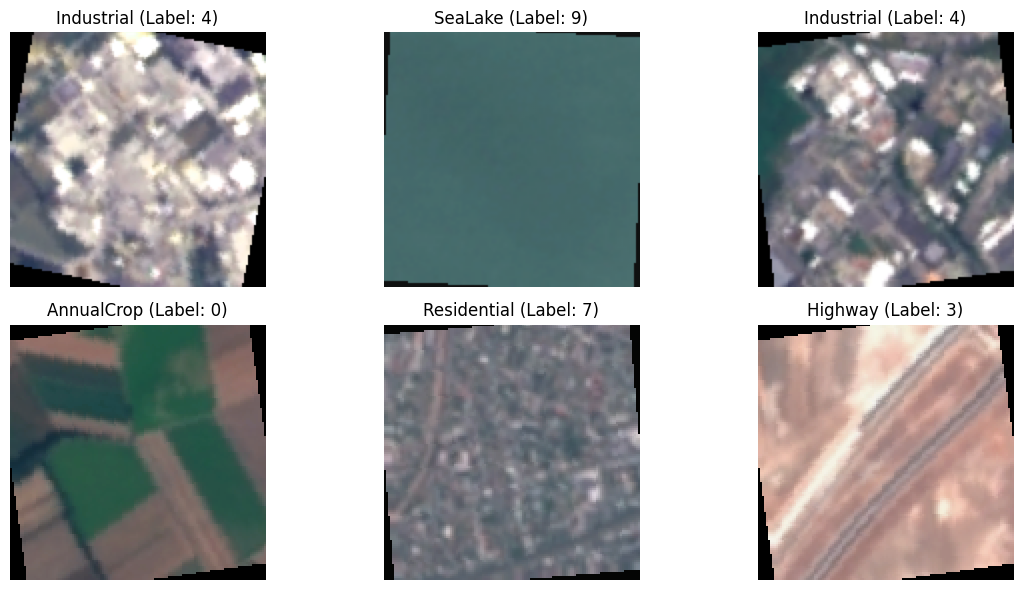

In [13]:

# DATA LOADING CONFIGURATION


batch_size = 32
num_workers = 0  # Set to 0 for Jupyter notebooks to avoid multiprocessing issues

print("Loading dataset...")
print(f"📁 Data root: {data_root}")
print(f"📄 Train CSV: {os.path.join(data_root, 'train.csv')}")
print(f"📄 Val CSV:    {os.path.join(data_root, 'validation.csv')}")
print(f"📄 Test CSV:   {os.path.join(data_root, 'test.csv')}")

train_loader, val_loader, test_loader, class_names = create_dataloaders(
    data_root=data_root,
    batch_size=batch_size,
    num_workers=num_workers
)

print(f"\n✅ Dataset loaded successfully!")
print(f"   Number of classes: {len(class_names)}")
print(f"   Classes: {class_names}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

# Fetch one batch
sample_batch = next(iter(train_loader))
images, labels, class_names_batch = sample_batch
print(f"\n   Sample batch shape: {images.shape}")
print(f"   Sample labels: {labels[:5].tolist()}")
print(f"   Sample class names: {class_names_batch[:5]}")


# SHOW SAMPLE IMAGES

import matplotlib.pyplot as plt
import torchvision.transforms as T

# Denormalization 
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def show_images(images, labels, names, num=6):
    """Display a few sample images with labels."""
    plt.figure(figsize=(12, 6))
    for i in range(min(num, len(images))):
        img = images[i]

        # De-normalize for display
        img = inv_normalize(img)
        img = img.permute(1, 2, 0).numpy()
        img = img.clip(0, 1)  # safety clip

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{names[i]} (Label: {labels[i].item()})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("\n📸 Showing sample images from train loader...")
show_images(images, labels, class_names_batch)


---

## 5. Model 1: Vision Transformer (ViT) - Pretrained



In [14]:
# ============================================================================
# CREATE ViT MODEL (PRETRAINED)
# ============================================================================

print("Creating ViT-Base model with pretrained weights...")
print("Model: vit_base_patch16_224")
print("Pretrained on: ImageNet-21k → ImageNet-1k")

# Load pretrained ViT from timm
vit_model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,  # Use pretrained weights!
    num_classes=len(class_names),
    img_size=128  # Our image size
)

# Count parameters
total_params, trainable_params = count_parameters(vit_model)
print(f"\n✅ ViT Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['ViT'] = {
    'model': vit_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating ViT-Base model with pretrained weights...
Model: vit_base_patch16_224
Pretrained on: ImageNet-21k → ImageNet-1k

✅ ViT Model Created!
   Total parameters: 85,704,970
   Trainable parameters: 85,704,970
   Model type: PRETRAINED (Transfer Learning)


In [15]:
# ============================================================================
# TRAIN ViT MODEL
# ============================================================================

# Train ViT with fewer epochs for CPU (can increase if needed)
vit_model, vit_history, vit_test_metrics = train_model(
    model=vit_model,
    model_name='ViT',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=10,  # Reduced for CPU training
    learning_rate=0.0001,  # Lower LR for fine-tuning pretrained model
    early_stopping_patience=5
)

# Store results
all_model_results['ViT']['history'] = vit_history
all_model_results['ViT']['test_metrics'] = vit_test_metrics
all_model_results['ViT']['test_accuracy'] = vit_test_metrics['accuracy']



Training ViT

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:08<00:00,  2.45it/s, loss=0.187] 



Train Loss: 0.4099 | Train Acc: 0.8605 | Train F1: 0.8579
Val Loss: 0.2263 | Val Acc: 0.9246 | Val F1: 0.9250
💾 Best model saved! (Val Loss: 0.2263)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:07<00:00,  2.52it/s, loss=0.0893]



Train Loss: 0.2037 | Train Acc: 0.9291 | Train F1: 0.9282
Val Loss: 0.1322 | Val Acc: 0.9572 | Val F1: 0.9560
💾 Best model saved! (Val Loss: 0.1322)

Epoch 3/10
------------------------------------------------------------


...


Train Loss: 0.1356 | Train Acc: 0.9534 | Train F1: 0.9527
Val Loss: 0.1874 | Val Acc: 0.9313 | Val F1: 0.9296

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:08<00:00,  2.46it/s, loss=0.00915]



Train Loss: 0.1329 | Train Acc: 0.9561 | Train F1: 0.9551
Val Loss: 0.1092 | Val Acc: 0.9622 | Val F1: 0.9612

Training completed in 135.57 minutes

Evaluating ViT on test set...


Validation: 100%|██████████| 85/85 [00:34<00:00,  2.47it/s, loss=0.00761]


📊 Test Results for ViT:
   Loss: 0.0928
   Accuracy: 0.9700
   F1-Macro: 0.9688
   F1-Weighted: 0.9700
   Balanced Accuracy: 0.9691


---

## 6. Model 2: ResNet-18 - Pretrained




In [16]:
# ============================================================================
# CREATE RESNET-18 MODEL (PRETRAINED)
# ============================================================================

print("Creating ResNet-18 model with pretrained weights...")
print("Pretrained on: ImageNet-1k")

# Load pretrained ResNet-18
resnet_model = models.resnet18(pretrained=True)

# Replace the final classification layer
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, len(class_names))

# Count parameters
total_params, trainable_params = count_parameters(resnet_model)
print(f"\n✅ ResNet-18 Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['ResNet-18'] = {
    'model': resnet_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/shoumik/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


Creating ResNet-18 model with pretrained weights...
Pretrained on: ImageNet-1k


100%|██████████| 44.7M/44.7M [00:02<00:00, 18.0MB/s]


✅ ResNet-18 Model Created!
   Total parameters: 11,181,642
   Trainable parameters: 11,181,642
   Model type: PRETRAINED (Transfer Learning)


In [17]:
# ============================================================================
# TRAIN RESNET-18 MODEL
# ============================================================================

resnet_model, resnet_history, resnet_test_metrics = train_model(
    model=resnet_model,
    model_name='ResNet-18',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=10,
    learning_rate=0.0001,
    early_stopping_patience=5
)

# Store results
all_model_results['ResNet-18']['history'] = resnet_history
all_model_results['ResNet-18']['test_metrics'] = resnet_test_metrics
all_model_results['ResNet-18']['test_accuracy'] = resnet_test_metrics['accuracy']



Training ResNet-18

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:29<00:00,  1.89it/s, loss=0.0262]



Train Loss: 0.3602 | Train Acc: 0.8807 | Train F1: 0.8783
Val Loss: 0.1405 | Val Acc: 0.9528 | Val F1: 0.9521
💾 Best model saved! (Val Loss: 0.1405)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:28<00:00,  1.90it/s, loss=0.0278] 



Train Loss: 0.2058 | Train Acc: 0.9321 | Train F1: 0.9308
Val Loss: 0.1059 | Val Acc: 0.9656 | Val F1: 0.9642
💾 Best model saved! (Val Loss: 0.1059)

Epoch 3/10
------------------------------------------------------------


...


Train Loss: 0.1062 | Train Acc: 0.9633 | Train F1: 0.9626
Val Loss: 0.0794 | Val Acc: 0.9733 | Val F1: 0.9724

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:28<00:00,  1.92it/s, loss=0.0182] 



Train Loss: 0.0948 | Train Acc: 0.9676 | Train F1: 0.9670
Val Loss: 0.0816 | Val Acc: 0.9717 | Val F1: 0.9710

Training completed in 120.58 minutes

Evaluating ResNet-18 on test set...


Validation: 100%|██████████| 85/85 [00:42<00:00,  1.99it/s, loss=0.000302]


📊 Test Results for ResNet-18:
   Loss: 0.0650
   Accuracy: 0.9793
   F1-Macro: 0.9786
   F1-Weighted: 0.9793
   Balanced Accuracy: 0.9790


---

## 7. Model 3: EfficientNet-B0 - Pretrained





In [18]:
# ============================================================================
# CREATE EFFICIENTNET-B0 MODEL (PRETRAINED)
# ============================================================================

print("Creating EfficientNet-B0 model with pretrained weights...")
print("Pretrained on: ImageNet-1k")

# Load pretrained EfficientNet-B0
efficientnet_model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,
    num_classes=len(class_names)
)

# Count parameters
total_params, trainable_params = count_parameters(efficientnet_model)
print(f"\n✅ EfficientNet-B0 Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['EfficientNet-B0'] = {
    'model': efficientnet_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating EfficientNet-B0 model with pretrained weights...
Pretrained on: ImageNet-1k

✅ EfficientNet-B0 Model Created!
   Total parameters: 4,020,358
   Trainable parameters: 4,020,358
   Model type: PRETRAINED (Transfer Learning)


In [35]:
# ============================================================================
# TRAIN EFFICIENTNET-B0 MODEL
# ============================================================================

efficientnet_model, efficientnet_history, efficientnet_test_metrics = train_model(
    model=efficientnet_model,
    model_name='EfficientNet-B0',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=2,
    learning_rate=0.0001,
    early_stopping_patience=5
)

# Store results
all_model_results['EfficientNet-B0']['history'] = efficientnet_history
all_model_results['EfficientNet-B0']['test_metrics'] = efficientnet_test_metrics
all_model_results['EfficientNet-B0']['test_accuracy'] = efficientnet_test_metrics['accuracy']



Training EfficientNet-B0

Epoch 1/2
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [02:41<00:00,  1.04it/s, loss=0.133] 



Train Loss: 0.6724 | Train Acc: 0.7979 | Train F1: 0.7936
Val Loss: 0.2321 | Val Acc: 0.9219 | Val F1: 0.9208
💾 Best model saved! (Val Loss: 0.2321)

Epoch 2/2
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [02:42<00:00,  1.04it/s, loss=0.062] 



Train Loss: 0.2779 | Train Acc: 0.9060 | Train F1: 0.9042
Val Loss: 0.1482 | Val Acc: 0.9465 | Val F1: 0.9457
💾 Best model saved! (Val Loss: 0.1482)

Training completed in 86.29 minutes

Evaluating EfficientNet-B0 on test set...


Validation: 100%|██████████| 85/85 [01:20<00:00,  1.05it/s, loss=0.00894]


📊 Test Results for EfficientNet-B0:
   Loss: 0.1306
   Accuracy: 0.9581
   F1-Macro: 0.9571
   F1-Weighted: 0.9585
   Balanced Accuracy: 0.9581


---

## 8. Model 4: DenseNet-121 - Pretrained



In [29]:
# ============================================================================
# CREATE DENSENET-121 MODEL (PRETRAINED)
# ============================================================================

print("Creating DenseNet-121 model with pretrained weights...")
print("Pretrained on: ImageNet-1k")

# Load pretrained DenseNet-121
densenet_model = models.densenet121(pretrained=True)

# Replace the final classification layer
num_features = densenet_model.classifier.in_features
densenet_model.classifier = nn.Linear(num_features, len(class_names))

# Count parameters
total_params, trainable_params = count_parameters(densenet_model)
print(f"\n✅ DenseNet-121 Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['DenseNet-121'] = {
    'model': densenet_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating DenseNet-121 model with pretrained weights...
Pretrained on: ImageNet-1k

✅ DenseNet-121 Model Created!
   Total parameters: 6,964,106
   Trainable parameters: 6,964,106
   Model type: PRETRAINED (Transfer Learning)


In [30]:
# ============================================================================
# TRAIN DENSENET-121 MODEL
# ============================================================================

densenet_model, densenet_history, densenet_test_metrics = train_model(
    model=densenet_model,
    model_name='DenseNet-121',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=3,
    learning_rate=0.0001,
    early_stopping_patience=3
)

# Store results
all_model_results['DenseNet-121']['history'] = densenet_history
all_model_results['DenseNet-121']['test_metrics'] = densenet_test_metrics
all_model_results['DenseNet-121']['test_accuracy'] = densenet_test_metrics['accuracy']



Training DenseNet-121

Epoch 1/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [03:34<00:00,  1.27s/it, loss=0.0415]



Train Loss: 0.3466 | Train Acc: 0.8918 | Train F1: 0.8899
Val Loss: 0.1147 | Val Acc: 0.9656 | Val F1: 0.9646
💾 Best model saved! (Val Loss: 0.1147)

Epoch 2/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [03:37<00:00,  1.29s/it, loss=0.0112] 



Train Loss: 0.1606 | Train Acc: 0.9475 | Train F1: 0.9464
Val Loss: 0.0862 | Val Acc: 0.9681 | Val F1: 0.9670
💾 Best model saved! (Val Loss: 0.0862)

Epoch 3/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [03:37<00:00,  1.28s/it, loss=0.00358]



Train Loss: 0.1251 | Train Acc: 0.9583 | Train F1: 0.9575
Val Loss: 0.0717 | Val Acc: 0.9772 | Val F1: 0.9764
💾 Best model saved! (Val Loss: 0.0717)

Training completed in 94.27 minutes

Evaluating DenseNet-121 on test set...


Validation: 100%|██████████| 85/85 [01:48<00:00,  1.28s/it, loss=0.00816]


📊 Test Results for DenseNet-121:
   Loss: 0.0654
   Accuracy: 0.9819
   F1-Macro: 0.9815
   F1-Weighted: 0.9819
   Balanced Accuracy: 0.9803


---

## 9. Model 5: Simple CNN - From Scratch


In [31]:
# ============================================================================
# CREATE SIMPLE CNN MODEL (FROM SCRATCH)
# ============================================================================

class SimpleCNN(nn.Module):
    """Simple CNN architecture for LULC classification"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected layers
        # After 3 pooling operations: 128/2/2/2 = 16, so 16*16*128 = 32768
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Conv block 1
        x = self.pool(torch.relu(self.conv1(x)))
        
        # Conv block 2
        x = self.pool(torch.relu(self.conv2(x)))
        
        # Conv block 3
        x = self.pool(torch.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(-1, 128 * 16 * 16)
        
        # Fully connected layers
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

print("Creating Simple CNN model (from scratch)...")
simple_cnn_model = SimpleCNN(num_classes=len(class_names))

# Count parameters
total_params, trainable_params = count_parameters(simple_cnn_model)
print(f"\n✅ Simple CNN Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: FROM SCRATCH (no pretrained weights)")

# Store model info
all_model_results['Simple CNN'] = {
    'model': simple_cnn_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating Simple CNN model (from scratch)...

✅ Simple CNN Model Created!
   Total parameters: 16,876,106
   Trainable parameters: 16,876,106
   Model type: FROM SCRATCH (no pretrained weights)


In [32]:
# ============================================================================
# TRAIN SIMPLE CNN MODEL
# ============================================================================

# Use higher learning rate for from-scratch training
simple_cnn_model, simple_cnn_history, simple_cnn_test_metrics = train_model(
    model=simple_cnn_model,
    model_name='Simple CNN',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=15,  # More epochs for from-scratch training
    learning_rate=0.001,  # Higher LR for from-scratch
    early_stopping_patience=3
)

# Store results
all_model_results['Simple CNN']['history'] = simple_cnn_history
all_model_results['Simple CNN']['test_metrics'] = simple_cnn_test_metrics
all_model_results['Simple CNN']['test_accuracy'] = simple_cnn_test_metrics['accuracy']



Training Simple CNN

Epoch 1/15
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [00:24<00:00,  6.96it/s, loss=0.836]



Train Loss: 1.3870 | Train Acc: 0.4806 | Train F1: 0.4603
Val Loss: 0.8832 | Val Acc: 0.6417 | Val F1: 0.6171
💾 Best model saved! (Val Loss: 0.8832)

Epoch 2/15
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [00:24<00:00,  6.95it/s, loss=0.907]



Train Loss: 1.0159 | Train Acc: 0.6240 | Train F1: 0.6071
Val Loss: 0.7926 | Val Acc: 0.6939 | Val F1: 0.6790
💾 Best model saved! (Val Loss: 0.7926)

Epoch 3/15
------------------------------------------------------------


...


Train Loss: 0.4304 | Train Acc: 0.8524 | Train F1: 0.8475
Val Loss: 0.3164 | Val Acc: 0.8941 | Val F1: 0.8901
💾 Best model saved! (Val Loss: 0.3164)

Epoch 15/15
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [00:26<00:00,  6.28it/s, loss=0.196]



Train Loss: 0.4065 | Train Acc: 0.8601 | Train F1: 0.8554
Val Loss: 0.3489 | Val Acc: 0.8815 | Val F1: 0.8768

Training completed in 58.73 minutes

Evaluating Simple CNN on test set...


Validation: 100%|██████████| 85/85 [00:13<00:00,  6.22it/s, loss=0.222]


📊 Test Results for Simple CNN:
   Loss: 0.3127
   Accuracy: 0.8885
   F1-Macro: 0.8843
   F1-Weighted: 0.8875
   Balanced Accuracy: 0.8858


---

## 10. Model 6: Swin Transformer Tiny - Pretrained



In [33]:
# ============================================================================
# CREATE SWIN TRANSFORMER TINY MODEL (PRETRAINED)
# ============================================================================

print("Creating Swin Transformer Tiny model with pretrained weights...")
print("Pretrained on: ImageNet-1k")

# Load pretrained Swin Transformer Tiny
swin_model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=len(class_names),
    img_size=128
)

# Count parameters
total_params, trainable_params = count_parameters(swin_model)
print(f"\n✅ Swin Transformer Tiny Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model type: PRETRAINED (Transfer Learning)")

# Store model info
all_model_results['Swin Transformer'] = {
    'model': swin_model,
    'total_params': total_params,
    'trainable_params': trainable_params
}


Creating Swin Transformer Tiny model with pretrained weights...
Pretrained on: ImageNet-1k

✅ Swin Transformer Tiny Model Created!
   Total parameters: 27,521,284
   Trainable parameters: 27,521,284
   Model type: PRETRAINED (Transfer Learning)


/Users/shoumik/.pyenv/versions/3.11.8/envs/tpot-env/lib/python3.11/site-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:34.)
  idx_right = torch.bucketize(x, p)


In [34]:
# ============================================================================
# TRAIN SWIN TRANSFORMER MODEL
# ============================================================================

swin_model, swin_history, swin_test_metrics = train_model(
    model=swin_model,
    model_name='Swin Transformer',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=3,
    learning_rate=0.0001,
    early_stopping_patience=3
)

# Store results
all_model_results['Swin Transformer']['history'] = swin_history
all_model_results['Swin Transformer']['test_metrics'] = swin_test_metrics
all_model_results['Swin Transformer']['test_accuracy'] = swin_test_metrics['accuracy']



Training Swin Transformer

Epoch 1/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:00<00:00,  2.81it/s, loss=0.0106]



Train Loss: 0.2509 | Train Acc: 0.9181 | Train F1: 0.9164
Val Loss: 0.1040 | Val Acc: 0.9654 | Val F1: 0.9639
💾 Best model saved! (Val Loss: 0.1040)

Epoch 2/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:02<00:00,  2.71it/s, loss=0.0309] 



Train Loss: 0.1255 | Train Acc: 0.9589 | Train F1: 0.9581
Val Loss: 0.1302 | Val Acc: 0.9550 | Val F1: 0.9537

Epoch 3/3
------------------------------------------------------------


Validation: 100%|██████████| 169/169 [01:03<00:00,  2.67it/s, loss=0.00201]



Train Loss: 0.1006 | Train Acc: 0.9673 | Train F1: 0.9665
Val Loss: 0.0629 | Val Acc: 0.9781 | Val F1: 0.9776
💾 Best model saved! (Val Loss: 0.0629)

Training completed in 34.90 minutes

Evaluating Swin Transformer on test set...


Validation: 100%|██████████| 85/85 [00:32<00:00,  2.64it/s, loss=0.0007] 


📊 Test Results for Swin Transformer:
   Loss: 0.0525
   Accuracy: 0.9826
   F1-Macro: 0.9819
   F1-Weighted: 0.9826
   Balanced Accuracy: 0.9820


---

## 11. Model Comparison & Results

### 📊 **Compare All Models**

Let's compare the performance of all models and see which one performs best!


MODEL COMPARISON - TEST SET RESULTS

📊 Test Set Performance (sorted by Accuracy):
           Model  Accuracy  F1-Macro  F1-Weighted  Balanced Accuracy  Total Params  Trainable Params
Swin Transformer  0.982593  0.981914     0.982632           0.982033      27521284          27521284
    DenseNet-121  0.981852  0.981509     0.981859           0.980333       6964106           6964106
       ResNet-18  0.979259  0.978609     0.979276           0.979033      11181642          11181642
             ViT  0.970000  0.968809     0.970047           0.969067      85704970          85704970
 EfficientNet-B0  0.958148  0.957091     0.958467           0.958133       4020358           4020358
      Simple CNN  0.888519  0.884329     0.887547           0.885800      16876106          16876106


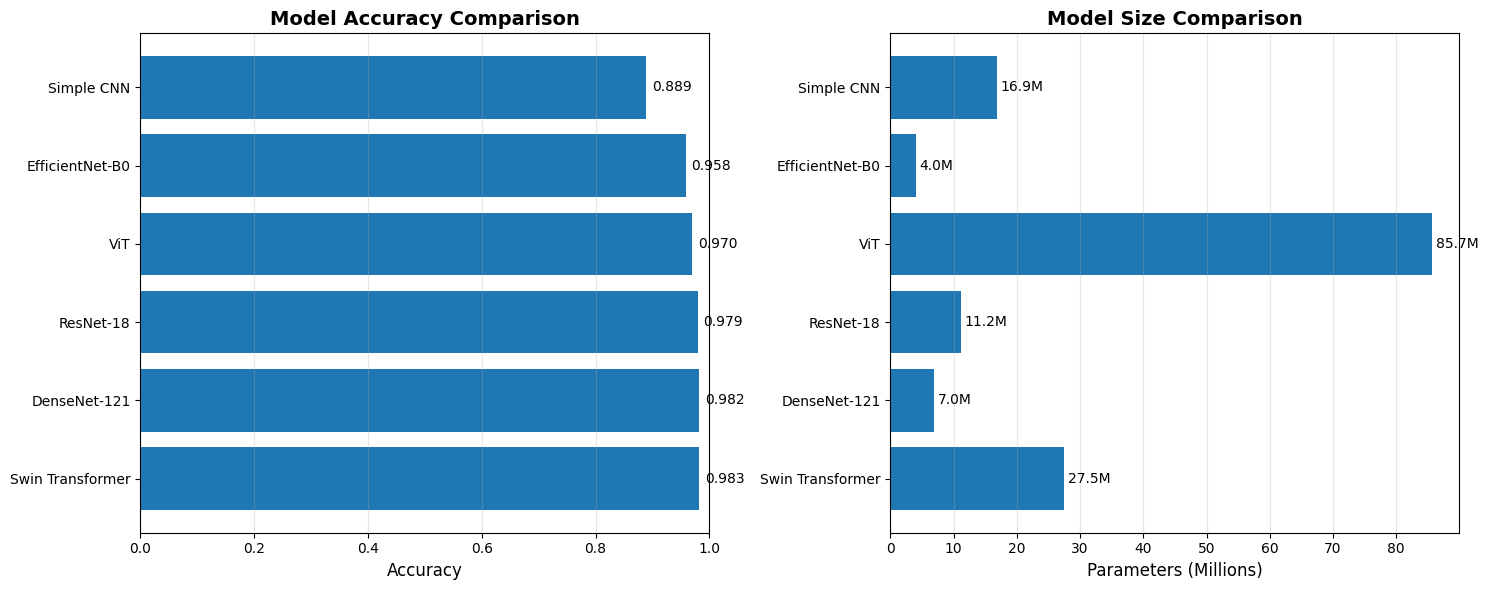


🏆 Best Model: Swin Transformer
   Accuracy: 0.9826
   F1-Macro: 0.9819


In [36]:
# ============================================================================
# COMPARE ALL MODELS
# ============================================================================

print("="*80)
print("MODEL COMPARISON - TEST SET RESULTS")
print("="*80)

# Create comparison dataframe
comparison_data = []
for model_name, results in all_model_results.items():
    if 'test_metrics' in results:
        comparison_data.append({
            'Model': model_name,
            'Accuracy': results['test_metrics']['accuracy'],
            'F1-Macro': results['test_metrics']['f1_macro'],
            'F1-Weighted': results['test_metrics']['f1_weighted'],
            'Balanced Accuracy': results['test_metrics']['balanced_accuracy'],
            'Total Params': results['total_params'],
            'Trainable Params': results['trainable_params']
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

# Display results
print("\n📊 Test Set Performance (sorted by Accuracy):")
print(comparison_df.to_string(index=False))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
axes[0].barh(comparison_df['Model'], comparison_df['Accuracy'])
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

# Parameter count comparison
axes[1].barh(comparison_df['Model'], comparison_df['Total Params'] / 1e6)
axes[1].set_xlabel('Parameters (Millions)', fontsize=12)
axes[1].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Total Params'] / 1e6):
    axes[1].text(v + 0.5, i, f'{v:.1f}M', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Find best model
best_model = comparison_df.iloc[0]
print(f"\n🏆 Best Model: {best_model['Model']}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   F1-Macro: {best_model['F1-Macro']:.4f}")


### 📄 **Comparison with Paper Results**



In [41]:
# ==============================================================
# PAPER vs OUR MODEL COMPARISON (EuroSAT - Test Accuracy)
# ==============================================================

import pandas as pd

# --- Paper accuracy values (Table-4, EuroSAT) ---
paper_results = {
    "Swin Transformer": 0.9828,   # SwinT-Small
    "ViT": 0.9870,                # ViT-Base
    "DenseNet": 0.9769,           # DenseNet-161 
    "CNN": 0.9422,    
    "ResNet-50": 0.9657               
}

# --- Your accuracy values from test metrics (screenshot) ---
our_results = {
    "Swin Transformer": all_model_results["Swin Transformer"]["test_metrics"]["accuracy"],
    "ViT": all_model_results["ViT"]["test_metrics"]["accuracy"],
    "DenseNet": all_model_results["DenseNet-121"]["test_metrics"]["accuracy"],
    "CNN": all_model_results["Simple CNN"]["test_metrics"]["accuracy"],
     "ResNet-18": all_model_results["ResNet-18"]["test_metrics"]["accuracy"]

}

# Create comparison DataFrame
compare_df = pd.DataFrame({
    "Model": list(paper_results.keys()),
    "Paper Accuracy": [paper_results[m] for m in paper_results],
    "Our Accuracy": [our_results[m] for m in our_results]
})

# Calculate difference (Our − Paper)
compare_df["Difference"] = compare_df["Our Accuracy"] - compare_df["Paper Accuracy"]

# Sort by Paper Accuracy (optional)
compare_df = compare_df.sort_values(by="Paper Accuracy", ascending=False).reset_index(drop=True)

print("\n📊 Paper vs Our Model Comparison (EuroSAT Test Accuracy)")
print(compare_df.to_string(index=False))


📊 Paper vs Our Model Comparison (EuroSAT Test Accuracy)
           Model  Paper Accuracy  Our Accuracy  Difference
             ViT          0.9870      0.970000   -0.017000
Swin Transformer          0.9828      0.982593   -0.000207
        DenseNet          0.9769      0.981852    0.004952
       ResNet-50          0.9657      0.979259    0.013559
             CNN          0.9422      0.888519   -0.053681
